In [1]:
# libraries we need
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)

# upload the csv file from my computer
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

display(df.head())
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print(df["Churn"].value_counts())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [3]:
df.info()
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [4]:
print("Missing values:")
print(df.isnull().sum())

print("Duplicate rows:", df.duplicated().sum())

# TotalCharges is text, so blanks may be hiding in it
blank_rows = df[df["TotalCharges"].str.strip() == ""]
print("Blank TotalCharges:", len(blank_rows))
display(blank_rows[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]])

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
Duplicate rows: 0
Blank TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [5]:
# turn TotalCharges into numbers, blanks become 0 (new customers paid nothing)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# customerID is just a label, so remove it
df = df.drop("customerID", axis=1)

# "No internet service" and "No phone service" both just mean "No"
df = df.replace({"No internet service": "No", "No phone service": "No"})

# make SeniorCitizen Yes/No like the other columns
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})

print(df.shape)
print(df["TotalCharges"].dtype)
display(df.head())

(7043, 20)
float64


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


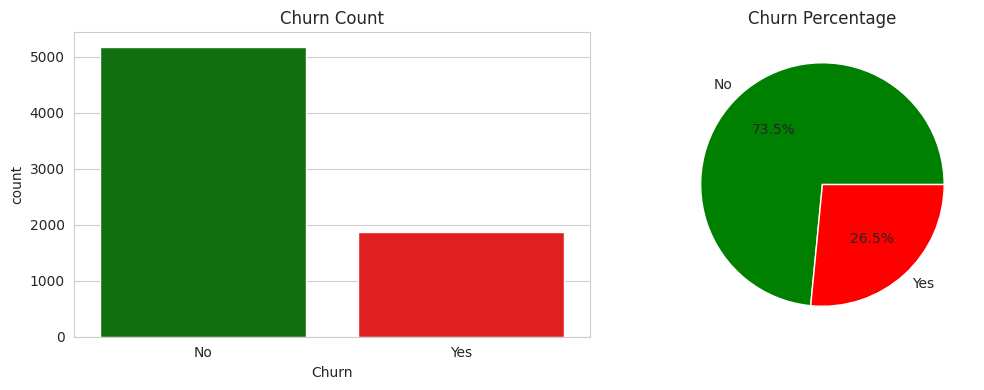

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

sns.countplot(x="Churn", data=df, palette=["green", "red"], ax=ax[0])
ax[0].set_title("Churn Count")

counts = df["Churn"].value_counts()
ax[1].pie(counts, labels=counts.index, autopct="%1.1f%%", colors=["green", "red"])
ax[1].set_title("Churn Percentage")

plt.tight_layout()
plt.show()

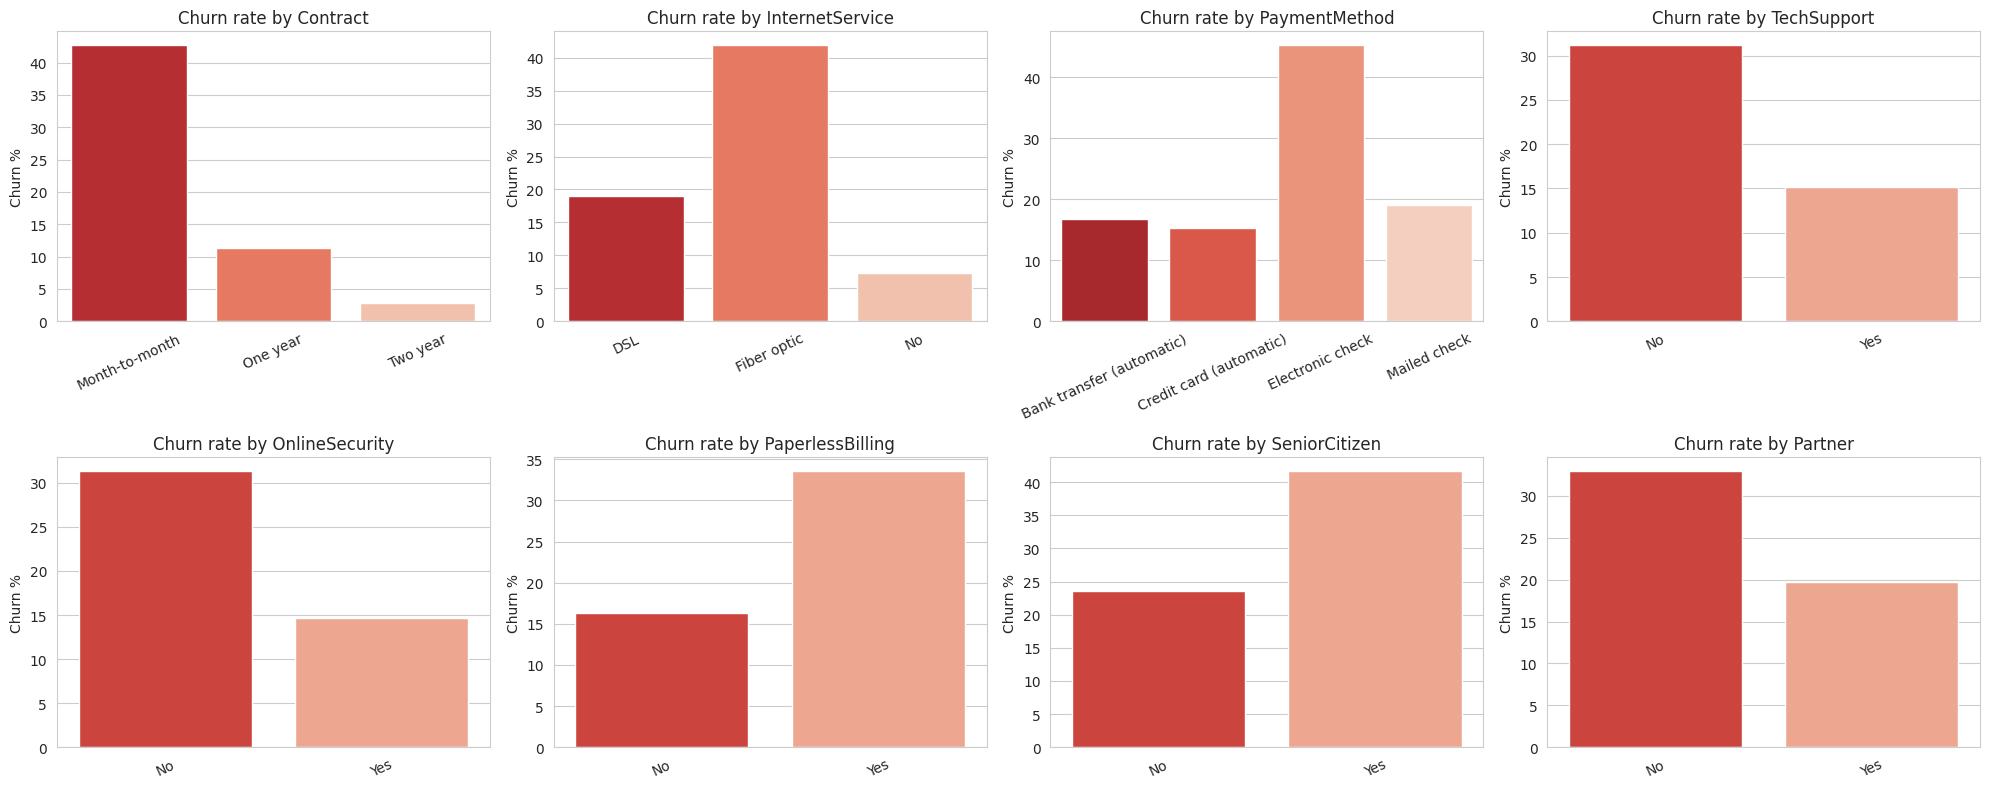

,Churn %
Contract,
Month-to-month,42.7
One year,11.3
Two year,2.8


,Churn %
InternetService,
DSL,19.0
Fiber optic,41.9
No,7.4


,Churn %
PaymentMethod,
Bank transfer (automatic),16.7
Credit card (automatic),15.2
Electronic check,45.3
Mailed check,19.1


In [7]:
# temporary 0/1 column so we can calculate churn percentages
df["churn_num"] = df["Churn"].map({"Yes": 1, "No": 0})

columns_to_check = ["Contract", "InternetService", "PaymentMethod", "TechSupport",
                    "OnlineSecurity", "PaperlessBilling", "SeniorCitizen", "Partner"]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.ravel()

for i in range(len(columns_to_check)):
    col = columns_to_check[i]
    rate = df.groupby(col)["churn_num"].mean() * 100
    sns.barplot(x=rate.index, y=rate.values, palette="Reds_r", ax=axes[i])
    axes[i].set_title("Churn rate by " + col)
    axes[i].set_ylabel("Churn %")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

# same thing as tables
for col in ["Contract", "InternetService", "PaymentMethod"]:
    display((df.groupby(col)["churn_num"].mean() * 100).round(1).to_frame("Churn %"))

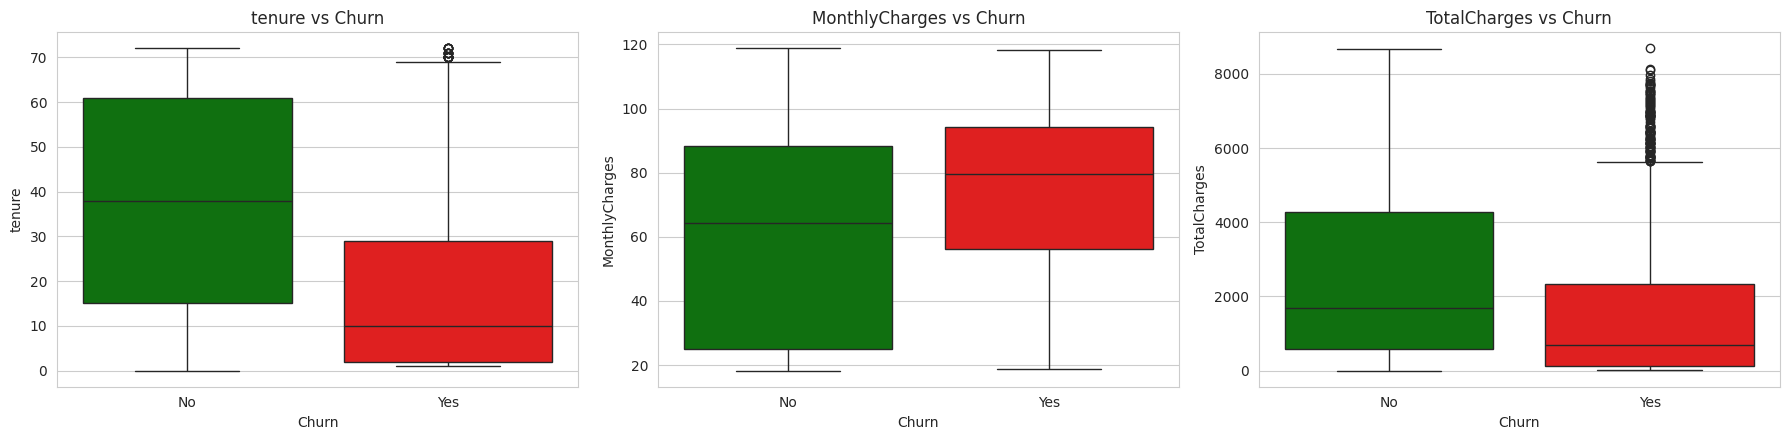

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.57,61.27,2549.91
Yes,17.98,74.44,1531.80


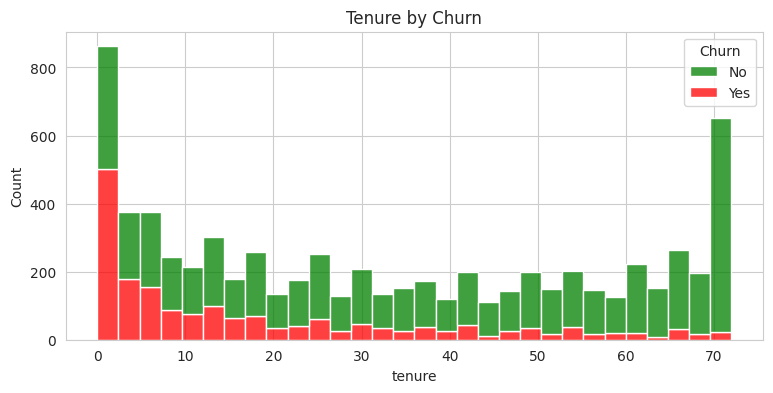

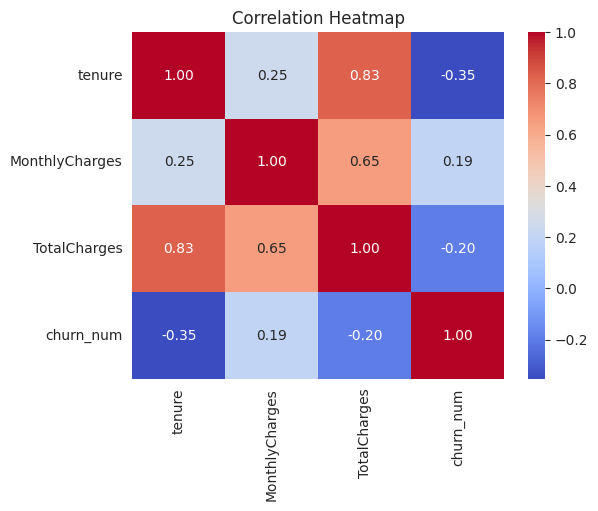

In [8]:
# box plots
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for i, col in enumerate(["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.boxplot(x="Churn", y=col, data=df, palette=["green", "red"], ax=axes[i])
    axes[i].set_title(col + " vs Churn")
plt.tight_layout()
plt.show()

# average values
display(df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].mean().round(2))

# tenure histogram
plt.figure(figsize=(9, 4))
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, multiple="stack", palette=["green", "red"])
plt.title("Tenure by Churn")
plt.show()

# correlation heatmap
plt.figure(figsize=(6, 4.5))
sns.heatmap(df[["tenure", "MonthlyCharges", "TotalCharges", "churn_num"]].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [9]:
# --- new features ---
addon_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
              "TechSupport", "StreamingTV", "StreamingMovies"]

df["num_addons"] = (df[addon_cols] == "Yes").sum(axis=1)     # how many add-ons
df["tenure_group"] = pd.cut(df["tenure"], bins=[-1, 12, 24, 48, 100],
                            labels=["0-12m", "13-24m", "25-48m", "49m+"]).astype(str)

# --- binary columns -> 0/1 ---
binary_cols = ["gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService",
               "MultipleLines", "PaperlessBilling"] + addon_cols
for col in binary_cols:
    df[col] = df[col].map({"Yes": 1, "No": 0, "Male": 1, "Female": 0})

# --- columns with 3+ categories -> one-hot encoding ---
onehot_cols = ["InternetService", "Contract", "PaymentMethod", "tenure_group"]
df = pd.get_dummies(df, columns=onehot_cols, dtype=int)

# --- separate inputs (X) and target (y) ---
y = df["Churn"].map({"Yes": 1, "No": 0})
X = df.drop(["Churn", "churn_num"], axis=1)

print("X shape:", X.shape)
print("y shape:", y.shape)
display(X.head())

X shape: (7043, 31)
y shape: (7043,)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,num_addons,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_0-12m,tenure_group_13-24m,tenure_group_25-48m,tenure_group_49m+
0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,29.85,29.85,1,1,0,0,1,0,0,0,0,1,0,1,0,0,0
1,1,0,0,0,34,1,0,1,0,1,0,0,0,0,56.95,1889.50,2,1,0,0,0,1,0,0,0,0,1,0,0,1,0
2,1,0,0,0,2,1,0,1,1,0,0,0,0,1,53.85,108.15,2,1,0,0,1,0,0,0,0,0,1,1,0,0,0
3,1,0,0,0,45,0,0,1,0,1,1,0,0,0,42.30,1840.75,3,1,0,0,0,1,0,1,0,0,0,0,0,1,0
4,0,0,0,0,2,1,0,0,0,0,0,0,0,1,70.70,151.65,0,0,1,0,1,0,0,0,0,1,0,1,0,0,0


In [10]:
# 80% training, 20% testing (stratify keeps the same churn ratio in both)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print("Train:", X_train.shape, "Test:", X_test.shape)

# scale the numeric columns (fit only on training data)
num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "num_addons"]
scaler = StandardScaler()
X_train_s = X_train.copy()
X_test_s = X_test.copy()
X_train_s[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_s[num_cols] = scaler.transform(X_test[num_cols])

# the three models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=5,
                                            class_weight="balanced", random_state=42),
}

for name in models:
    models[name].fit(X_train_s, y_train)
    print(name, "trained")

Train: (5634, 31) Test: (1409, 31)
Logistic Regression trained
Decision Tree trained
Random Forest trained


In [11]:
results = []
predictions = {}

for name in models:
    y_pred = models[name].predict(X_test_s)
    predictions[name] = y_pred
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
    })

results_df = pd.DataFrame(results).set_index("Model").round(3)
display(results_df)

for name in predictions:
    print("=" * 55)
    print(name)
    print(classification_report(y_test, predictions[name], target_names=["No Churn", "Churn"]))

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.732,0.497,0.791,0.611
Decision Tree,0.756,0.527,0.791,0.632
Random Forest,0.764,0.538,0.786,0.639


Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.90      0.71      0.80      1035
       Churn       0.50      0.79      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.73      0.75      1409

Decision Tree
              precision    recall  f1-score   support

    No Churn       0.91      0.74      0.82      1035
       Churn       0.53      0.79      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.76      0.77      1409

Random Forest
              precision    recall  f1-score   support

    No Churn       0.91      0.76      0.83      1035
       Churn       0.54      0.79      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81   

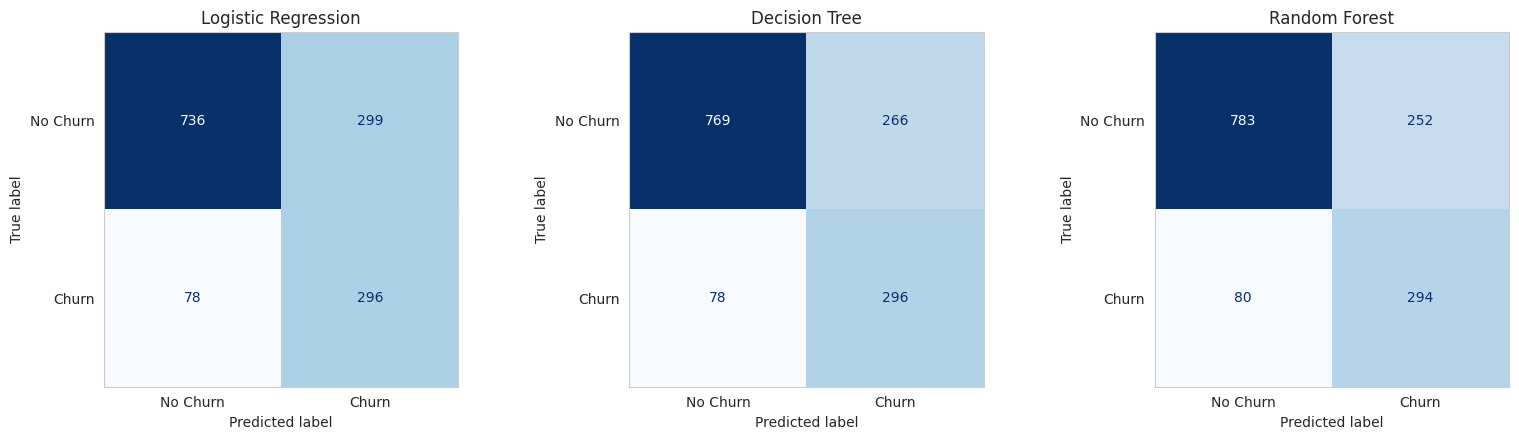

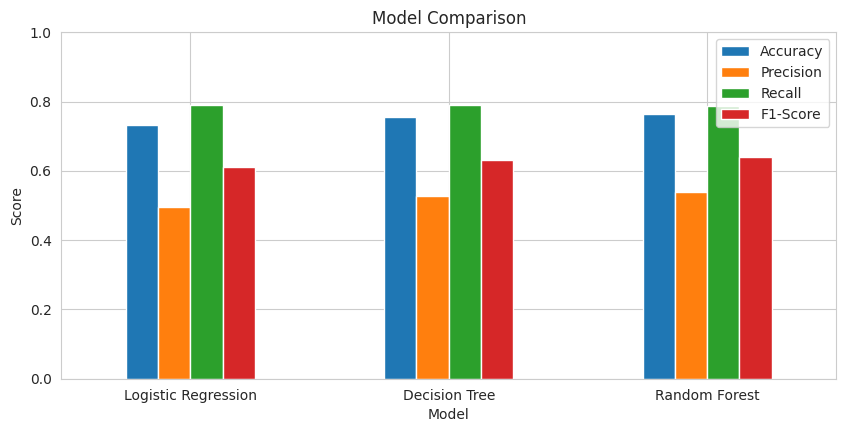

Best model: Random Forest
Accuracy     0.764
Precision    0.538
Recall       0.786
F1-Score     0.639
Name: Random Forest, dtype: float64


In [12]:
# confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for i, name in enumerate(predictions):
    cm = confusion_matrix(y_test, predictions[name])
    ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"]).plot(ax=axes[i], cmap="Blues", colorbar=False)
    axes[i].set_title(name)
    axes[i].grid(False)
plt.tight_layout()
plt.show()

# comparison chart
results_df.plot(kind="bar", figsize=(10, 4.5))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

# pick the best model using F1-score
best_name = results_df["F1-Score"].idxmax()
final_model = models[best_name]
print("Best model:", best_name)
print(results_df.loc[best_name])

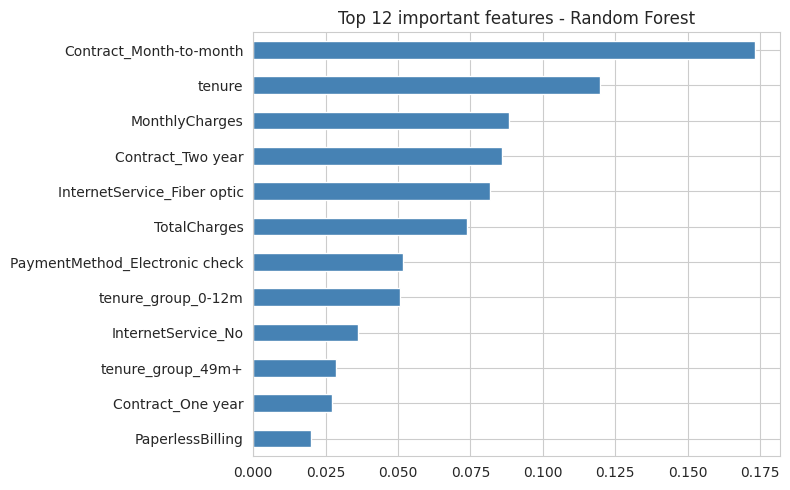

Contract_Month-to-month           0.173
tenure                            0.120
MonthlyCharges                    0.088
Contract_Two year                 0.086
InternetService_Fiber optic       0.082
TotalCharges                      0.074
PaymentMethod_Electronic check    0.052
tenure_group_0-12m                0.051
InternetService_No                0.036
tenure_group_49m+                 0.028
Contract_One year                 0.027
PaperlessBilling                  0.020
dtype: float64


In [13]:
if hasattr(final_model, "feature_importances_"):
    importance = pd.Series(final_model.feature_importances_, index=X.columns)
else:
    importance = pd.Series(final_model.coef_[0], index=X.columns)

top12 = importance.abs().sort_values(ascending=False).head(12)

plt.figure(figsize=(8, 5))
top12.sort_values().plot(kind="barh", color="steelblue")
plt.title("Top 12 important features - " + best_name)
plt.tight_layout()
plt.show()

print(top12.round(3))

In [14]:
def predict_customer(info):
    # turn the customer details into one row and prepare it exactly like the training data
    row = pd.DataFrame([info])

    row["num_addons"] = (row[addon_cols] == "Yes").sum(axis=1)
    row["tenure_group"] = pd.cut(row["tenure"], bins=[-1, 12, 24, 48, 100],
                                 labels=["0-12m", "13-24m", "25-48m", "49m+"]).astype(str)

    for col in binary_cols:
        row[col] = row[col].map({"Yes": 1, "No": 0, "Male": 1, "Female": 0})

    row = pd.get_dummies(row, columns=onehot_cols, dtype=int)
    row = row.reindex(columns=X.columns, fill_value=0)      # same columns as training data
    row[num_cols] = scaler.transform(row[num_cols])          # same scaling

    pred = final_model.predict(row)[0]
    prob = final_model.predict_proba(row)[0][1]
    return ("CHURN" if pred == 1 else "NO CHURN"), prob


customer_a = {"gender": "Female", "SeniorCitizen": "No", "Partner": "No", "Dependents": "No",
              "tenure": 2, "PhoneService": "Yes", "MultipleLines": "No",
              "InternetService": "Fiber optic", "OnlineSecurity": "No", "OnlineBackup": "No",
              "DeviceProtection": "No", "TechSupport": "No", "StreamingTV": "Yes",
              "StreamingMovies": "Yes", "Contract": "Month-to-month", "PaperlessBilling": "Yes",
              "PaymentMethod": "Electronic check", "MonthlyCharges": 95.5, "TotalCharges": 191.0}

customer_b = {"gender": "Male", "SeniorCitizen": "No", "Partner": "Yes", "Dependents": "Yes",
              "tenure": 60, "PhoneService": "Yes", "MultipleLines": "Yes",
              "InternetService": "DSL", "OnlineSecurity": "Yes", "OnlineBackup": "Yes",
              "DeviceProtection": "Yes", "TechSupport": "Yes", "StreamingTV": "No",
              "StreamingMovies": "No", "Contract": "Two year", "PaperlessBilling": "No",
              "PaymentMethod": "Bank transfer (automatic)", "MonthlyCharges": 70.0, "TotalCharges": 4200.0}

customer_c = {"gender": "Female", "SeniorCitizen": "Yes", "Partner": "No", "Dependents": "No",
              "tenure": 18, "PhoneService": "Yes", "MultipleLines": "No",
              "InternetService": "Fiber optic", "OnlineSecurity": "No", "OnlineBackup": "Yes",
              "DeviceProtection": "No", "TechSupport": "No", "StreamingTV": "No",
              "StreamingMovies": "No", "Contract": "One year", "PaperlessBilling": "Yes",
              "PaymentMethod": "Credit card (automatic)", "MonthlyCharges": 80.0, "TotalCharges": 1440.0}

print("Model used:", best_name)
for label, cust in [("Customer A", customer_a), ("Customer B", customer_b), ("Customer C", customer_c)]:
    result, probability = predict_customer(cust)
    print(label, "->", result, "(churn probability: {:.1%})".format(probability))

Model used: Random Forest
Customer A -> CHURN (churn probability: 89.3%)
Customer B -> NO CHURN (churn probability: 4.1%)
Customer C -> NO CHURN (churn probability: 26.5%)
